In [1]:
import numpy as np
import pandas as pd
import random
from sklearn.linear_model import LogisticRegression
import sys

sys.path.insert(0, "../Modules")

pd.set_option('display.max_columns', None)
random.seed(0)
np.random.seed(0)

from utils import *

In [2]:
NUTS0 = 'GR'
NUTS2 = 'Thessaly'

In [3]:
f = open(f"data/{NUTS0}_WNV_{NUTS2}_cases_dates.txt", "r")
print(f.read())

months: 7, 8, 9, 10, 
years: 2010, 2011, 2018, 2019, 2020, 


In [4]:
r_u = 0.05
near_u = 0.25
smote = 1
scaler = 'minmax'
#years_to_remove = [year for year in range(2012, 2018)]
years_to_remove = []
path = f'data/{NUTS0}_{NUTS2}_WNV_Dataset_2010_2021.csv'

In [5]:
dataset = read_data(path, exclude_years = years_to_remove)
dataset.head()

,x,y,dt_placement,nuts2,lau1,lau1_id,day,month,week,year,day_sin,day_cos,month_sin,month_cos,week_sin,week_cos,area,population,population_density,eq_distance,ndvi,ndmi,ndwi,ndbi,ndvi_mean,ndmi_mean,ndwi_mean,ndbi_mean,ndvi_std,ndmi_std,ndwi_std,ndbi_std,lst,lst_day,lst_night,lst_jan_day_mean,lst_jan_night_mean,lst_feb_day_mean,lst_feb_night_mean,lst_mar_day_mean,lst_mar_night_mean,lst_apr_day_mean,lst_apr_night_mean,acc_rainfall_1week,acc_rainfall_2week,acc_rainfall_jan,distance_to_coast,distance_to_river,slope_mean_1km,aspect_mean_200m,elevation_mean_1km,hillshade_mean_1km,fs_area_1km,flow_accu_200m,lc_prop1,lc_prop1_assessment,lc_prop2,lc_prop2_assessment,lc_prop3,lc_prop3_assessment,lc_type1,lc_type2,lc_type3,lc_type4,lc_type5,lw,qc,mosq_pred,mosq_previous,case
0,22.75027,39.71097,2010-01-01,θεσσαλιας,αγιας,22,1,1,53,2010,0.201299,0.97953,0.5,0.866025,-2.449294e-16,1.0,661.8,10705.0,17.3,45.76610,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,11.177143,14.644286,7.71,9.745684,4.044170,8.551413,3.117316,15.854022,4.895714,18.946151,6.782726,0.018327,0.018327,0.018327,8282.127022,1331.619869,1,123.585589,121.767859,183.036108,0.0,21.311709,22,76,20,76.0,20,76,9,9,4,2,2,2,0,4,0,0
1,22.69237,39.13639,2010-01-01,θεσσαλιας,αλμυρου,9,1,1,53,2010,0.201299,0.97953,0.5,0.866025,-2.449294e-16,1.0,905.4,16004.0,20.6,45.23937,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,14.237778,17.085556,11.39,10.578306,4.632088,11.594181,4.298405,18.102979,6.260191,21.063313,8.144888,0.210382,0.210382,0.210382,10017.207897,1610.666116,14,259.585198,342.571837,171.163634,0.0,3.415750,21,78,20,78.0,20,78,8,8,4,1,1,2,0,1,0,0
2,24.07379,39.32896,2010-01-01,θεσσαλιας,αλοννησου,24,1,1,53,2010,0.201299,0.97953,0.5,0.866025,-2.449294e-16,1.0,129.6,3153.0,21.2,46.11198,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,15.090000,17.810000,12.37,11.875455,10.167500,10.426667,8.035714,15.095333,9.928889,18.851600,10.540588,0.000000,0.000000,0.000000,1484.683259,55302.082778,24,302.637680,165.397106,195.027810,0.0,1.676994,21,93,20,93.0,20,93,8,8,4,1,1,2,0,1,0,0
3,21.43051,39.22138,2010-01-01,θεσσαλιας,αργιθεας,0,1,1,53,2010,0.201299,0.97953,0.5,0.866025,-2.449294e-16,1.0,372.9,3515.0,9.3,44.69433,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.274889,0.318889,3.929167,-0.943095,11.973413,2.839991,16.749405,6.439643,49.209201,49.209201,49.209201,17128.150567,2537.700531,21,116.335477,1163.031269,147.596517,0.0,1.107140,11,93,10,95.0,10,95,1,1,7,1,1,2,0,1,0,0
4,22.88380,39.35198,2010-01-01,θεσσαλιας,βολου,14,1,1,53,2010,0.201299,0.97953,0.5,0.866025,-2.449294e-16,1.0,385.6,138865.0,374.6,45.52194,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,18.383333,NaN,14.044643,4.790926,13.656768,4.280179,19.413810,6.542459,24.387230,8.781836,0.000000,0.000000,0.000000,5935.142744,3071.988689,5,143.181190,234.931813,174.426021,0.0,4.643743,31,95,30,95.0,30,95,10,10,1,6,6,2,0,1,0,0


In [6]:
dataset = dataset.query('month >= 6 & month <= 10')
dataset.reset_index(inplace=True, drop=True)

In [7]:
dataset

,x,y,dt_placement,nuts2,lau1,lau1_id,day,month,week,year,day_sin,day_cos,month_sin,month_cos,week_sin,week_cos,area,population,population_density,eq_distance,ndvi,ndmi,ndwi,ndbi,ndvi_mean,ndmi_mean,ndwi_mean,ndbi_mean,ndvi_std,ndmi_std,ndwi_std,ndbi_std,lst,lst_day,lst_night,lst_jan_day_mean,lst_jan_night_mean,lst_feb_day_mean,lst_feb_night_mean,lst_mar_day_mean,lst_mar_night_mean,lst_apr_day_mean,lst_apr_night_mean,acc_rainfall_1week,acc_rainfall_2week,acc_rainfall_jan,distance_to_coast,distance_to_river,slope_mean_1km,aspect_mean_200m,elevation_mean_1km,hillshade_mean_1km,fs_area_1km,flow_accu_200m,lc_prop1,lc_prop1_assessment,lc_prop2,lc_prop2_assessment,lc_prop3,lc_prop3_assessment,lc_type1,lc_type2,lc_type3,lc_type4,lc_type5,lw,qc,mosq_pred,mosq_previous,case
0,22.75027,39.71097,2010-06-01,θεσσαλιας,αγιας,22,1,6,22,2010,0.201299,0.979530,1.224647e-16,-1.0,0.508531,-0.861044,661.8,10705.00,17.3,45.76610,0.604547,0.239662,-0.369814,-0.239662,0.607976,0.259280,-0.354210,-0.259280,0.037878,0.038561,0.021209,0.038561,18.111429,24.678571,11.544286,9.745684,4.044170,8.551413,3.117316,15.854022,4.895714,18.946151,6.782726,19.315137,96.170273,594.289658,8282.127022,1331.619869,1,123.585589,121.767859,183.036108,0.0,21.311709,22,76,20,76.0,20,76,9,9,4,2,2,2,0,6,12,0
1,22.69237,39.13639,2010-06-01,θεσσαλιας,αλμυρου,9,1,6,22,2010,0.201299,0.979530,1.224647e-16,-1.0,0.508531,-0.861044,905.4,16004.00,20.6,45.23937,0.444394,0.139280,-0.304558,-0.139280,0.408037,0.132123,-0.267725,-0.132123,0.047592,0.051700,0.056671,0.051700,21.662222,28.567778,14.756667,10.578306,4.632088,11.594181,4.298405,18.102979,6.260191,21.063313,8.144888,16.832220,78.747570,576.739466,10017.207897,1610.666116,14,259.585198,342.571837,171.163634,0.0,3.415750,21,78,20,78.0,20,78,8,8,4,1,1,2,0,7,13,0
2,24.07379,39.32896,2010-06-01,θεσσαλιας,αλοννησου,24,1,6,22,2010,0.201299,0.979530,1.224647e-16,-1.0,0.508531,-0.861044,129.6,3153.00,21.2,46.11198,0.478159,0.116885,-0.324981,-0.116885,0.478648,0.107064,-0.344755,-0.107064,0.036931,0.045692,0.017288,0.045692,21.450000,22.830000,20.070000,11.875455,10.167500,10.426667,8.035714,15.095333,9.928889,18.851600,10.540588,107.927678,187.621050,723.397947,1484.683259,55302.082778,24,302.637680,165.397106,195.027810,0.0,1.676994,21,93,20,93.0,20,93,8,8,4,1,1,2,0,6,7,0
3,21.43051,39.22138,2010-06-01,θεσσαλιας,αργιθεας,0,1,6,22,2010,0.201299,0.979530,1.224647e-16,-1.0,0.508531,-0.861044,372.9,3515.00,9.3,44.69433,0.477639,0.247121,-0.159987,-0.247121,0.477005,0.247106,-0.161011,-0.247106,0.040277,0.029637,0.029210,0.029637,16.403333,22.970000,9.836667,0.274889,0.318889,3.929167,-0.943095,11.973413,2.839991,16.749405,6.439643,0.944009,9.219252,670.601435,17128.150567,2537.700531,21,116.335477,1163.031269,147.596517,0.0,1.107140,11,93,10,95.0,10,95,1,1,7,1,1,2,0,15,32,0
4,22.88380,39.35198,2010-06-01,θεσσαλιας,βολου,14,1,6,22,2010,0.201299,0.979530,1.224647e-16,-1.0,0.508531,-0.861044,385.6,138865.00,374.6,45.52194,0.425591,0.131988,-0.297548,-0.131988,0.325313,0.161796,-0.119200,-0.161796,0.020897,0.011268,0.012894,0.011268,21.530000,28.043333,15.016667,14.044643,4.790926,13.656768,4.280179,19.413810,6.542459,24.387230,8.781836,12.881553,80.054671,557.697795,5935.142744,3071.988689,5,143.181190,234.931813,174.426021,0.0,4.643743,31,95,30,95.0,30,95,10,10,1,6,6,2,0,8,11,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3031,22.55316,39.85211,2021-10-16,θεσσαλιας,τεμπων,23,16,10,41,2021,-0.101168,-0.994869,-8.660254e-01,0.5,-0.989040,0.147647,576.7,11.99,23.8,45.79122,0.496181,0.108527,-0.447561,-0.108527,0.494762,0.101525,-0.448295,-0.101525,0.062635,0.074820,0.037224,0.074820,21.208000,26.462000,15.954000,5.517741,0.477349,10.868515,4.723090,12.528034,2.774820,19.173602,5.501974,182.178094,252.8131

In [8]:
dsc = dataframe_describe(dataset)
dsc.head(15)

,year,non-case,case,total,percentage
0,2010,244,9,253,8.33%
1,2011,227,30,257,8.47%
2,2012,250,0,250,8.23%
3,2013,250,0,250,8.23%
4,2014,250,0,250,8.23%
5,2015,250,0,250,8.23%
6,2016,250,0,250,8.23%
7,2017,250,0,250,8.23%
8,2018,245,7,252,8.30%
9,2019,220,53,273,8.99%


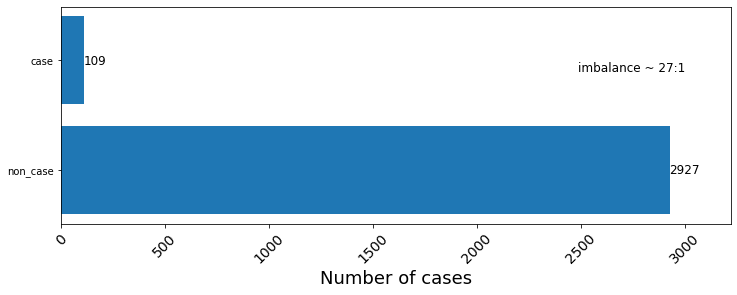

In [9]:
plot_imbalance(dataset)

In [10]:
coefficients = []
results_train = pd.DataFrame()
results_test = pd.DataFrame()
feature_names = dataset.select_dtypes(exclude=['object']).drop(columns = ['case']).columns

In [11]:
for train_idx, test_idx in yearCV_split(dataset):
    data_train = dataset.iloc[train_idx]
    data_test = dataset.iloc[test_idx]
    
    data_train.reset_index(inplace = True, drop = True)
    data_test.reset_index(inplace = True, drop = True)
    
    X_train = data_train.select_dtypes(exclude=['object']).drop(columns = ['case'])
    y_train = data_train['case']
    X_test = data_test.select_dtypes(exclude=['object']).drop(columns = ['case'])
    y_test = data_test['case']
    
    X_train, X_test, y_train, y_test, X_train_df = transform_data(X_train, X_test, y_train, y_test, r_u, near_u, smote, scaler_key=scaler)
    
    w0,w1 = calculate_weights(y_train)

    model = LogisticRegression(max_iter = 1000, class_weight = {0.0: w0, 1.0:w1}, n_jobs = -1, random_state = 0)
    
    train, test, coef = train_and_predict(model, X_train_df, data_test, X_train, y_train, X_test, y_test)
    
    results_train = results_train.append(train, ignore_index = True)
    results_test = results_test.append(test, ignore_index = True)
    coefficients.append(coef)
    
    print(f"Year: {test['year'].iloc[0]} || w0:{w0}, w1:{w1} || ##")

Year: 2010 || w0:1, w1:11 || ##
Year: 2011 || w0:1, w1:13 || ##
Year: 2012 || w0:1, w1:10 || ##
Year: 2013 || w0:1, w1:10 || ##
Year: 2014 || w0:1, w1:10 || ##
Year: 2015 || w0:1, w1:10 || ##
Year: 2016 || w0:1, w1:10 || ##
Year: 2017 || w0:1, w1:10 || ##
Year: 2018 || w0:1, w1:10 || ##
Year: 2019 || w0:1, w1:19 || ##
Year: 2020 || w0:1, w1:11 || ##
Year: 2021 || w0:1, w1:10 || ##


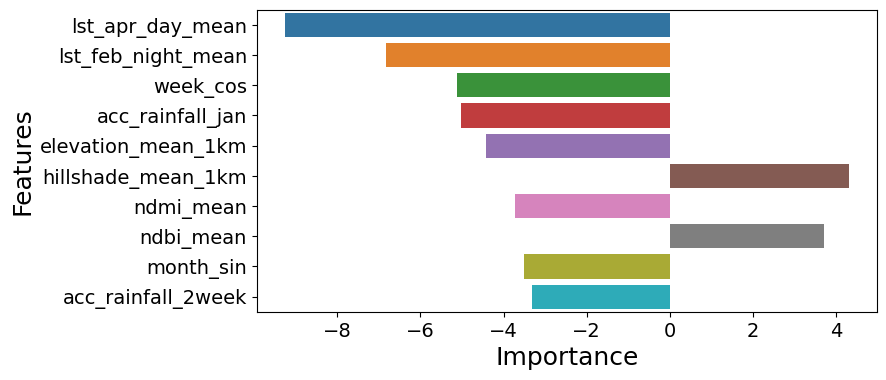

In [12]:
plot_feature_importance(coefficients, feature_names, top = 10, figure_size = (8, 4))

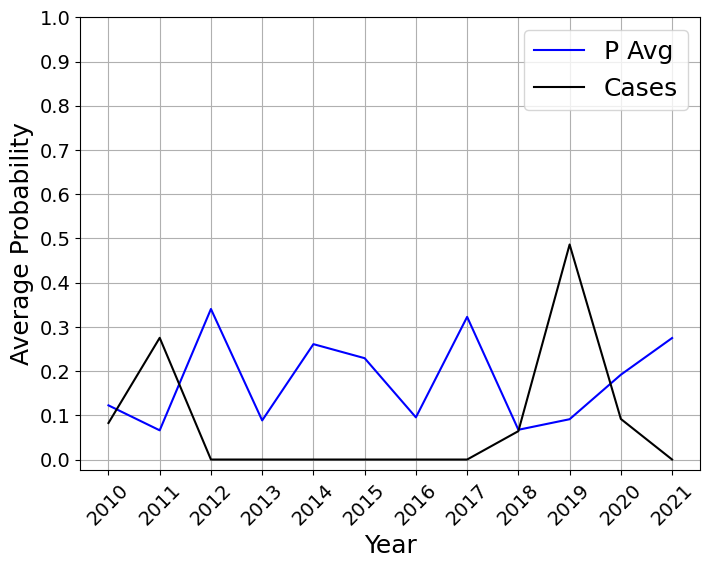

In [13]:
plot_trend_curve(results_test, list(dsc['case']))

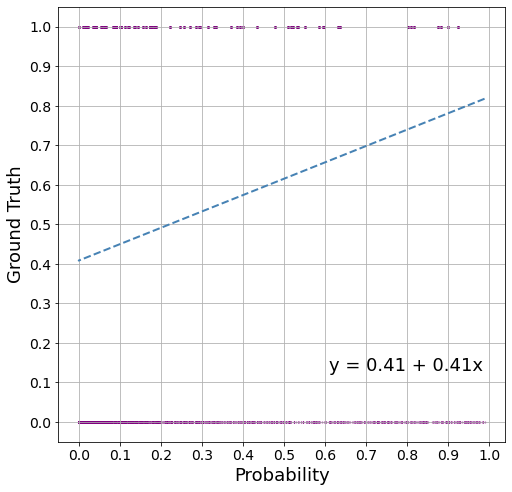

In [14]:
plot_probability_curve(results_test)

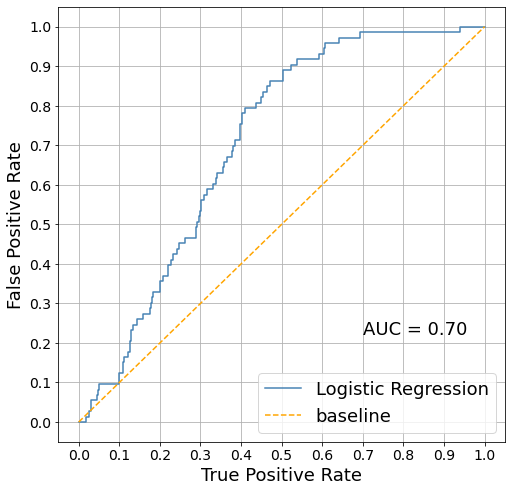

In [15]:
plot_roc_curve(results_test)

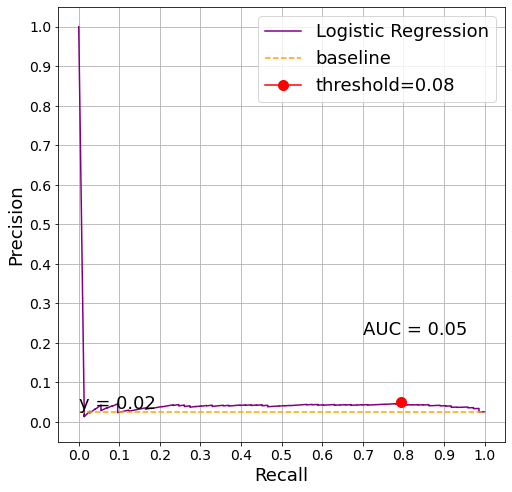

In [16]:
plot_pr_curve(results_test, plot_fbeta = True)

In [17]:
operational, cumulative, avg, weighted = evaluate_operational(results_test, k = 5, prob_threshold = -1)
print(f'Average: {avg*100:.2f}%\nWeighted Average: {weighted*100:.2f}%')

Average: 65.07%
Weighted Average: 58.39%


In [18]:
operational

,Prediction Date,Infected,Discovered,Out of,Percentage,percentage
0,01/06/2010,0,0,0,NaN,NaN
1,16/06/2010,0,0,0,NaN,NaN
2,01/07/2010,0,0,0,NaN,NaN
3,16/07/2010,1,0,1,0.00 %,0.0
4,01/08/2010,1,1,1,100.00 %,1.0
...,...,...,...,...,...,...
115,16/08/2021,0,0,0,NaN,NaN
116,01/09/2021,0,0,0,NaN,NaN
117,16/09/2021,0,0,0,NaN,NaN
118,01/10/2021,0,0,0,NaN,NaN


In [19]:
cumulative

,Year,Infected,Discovered,Out Of,Percentage,percentage
0,2010,6,5,6,83.33 %,0.8333
1,2011,23,9,19,47.37 %,0.4737
2,2012,0,0,0,nan %,NaN
3,2013,0,0,0,nan %,NaN
4,2014,0,0,0,nan %,NaN
5,2015,0,0,0,nan %,NaN
6,2016,0,0,0,nan %,NaN
7,2017,0,0,0,nan %,NaN
8,2018,5,4,5,80.00 %,0.8000
9,2019,30,13,22,59.09 %,0.5909


In [20]:
report_train, report_test = classification_report(results_train, results_test, threshold = 0.2, beta = 4)

In [21]:
report_test.head(15)

,Year,Infected,Positive Rate,Accuracy,Precision,Recall,F4 Score,Loss
0,2010,6.0000,0.1680,0.9262,0.1429,1.0000,0.7391,0.1721
1,2011,23.0000,0.0760,0.6018,0.3158,0.2609,0.2636,0.2398
2,2012,0.0000,0.5160,0.4840,0.0000,0.0000,0.0000,0.7026
3,2013,0.0000,0.1520,0.8480,0.0000,0.0000,0.0000,0.1154
4,2014,0.0000,0.4640,0.5360,0.0000,0.0000,0.0000,0.4298
5,2015,0.0000,0.3560,0.6440,0.0000,0.0000,0.0000,0.4151
6,2016,0.0000,0.1520,0.8480,0.0000,0.0000,0.0000,0.1227
7,2017,0.0000,0.5120,0.4880,0.0000,0.0000,0.0000,0.5781
8,2018,5.0000,0.1000,0.5510,0.0400,0.2000,0.1619,0.1657
9,2019,30.0000,0.1400,0.7045,0.4286,0.5000,0.4951,0.2930
